# Introduction to Clustering in Python

In this lecture, we focus on the **basic idea of clustering** and one simple method: **K-means clustering**.

We will **not** cover hierarchical clustering in this notebook.

## Learning goals

By the end of this lecture, you should be able to:

- explain what clustering is and why it is **unsupervised learning**
- describe how clustering relates to (and differs from) **KNN** from last week
- describe the basic idea of **K-means**
- run a simple clustering example in Python
- interpret the clustering result on a scatter plot and in plain business language

## 1. A bridge from last week: KNN vs K-means

Last week we studied **KNN (K-Nearest Neighbors)**. This week we study **K-means clustering**. The names sound similar and both use the letter **K**, but they are very different methods.

| Aspect | KNN (last week) | K-means (today) |
|---|---|---|
| Type of learning | **Supervised** | **Unsupervised** |
| Do we have labels $y$? | Yes | No |
| What does $K$ mean? | Number of **neighbors** to look at | Number of **clusters** to form |
| What does it use distance for? | To find the closest labeled neighbors | To group unlabeled points together |
| Need to scale features? | Yes | Yes |

The most important thing to remember:

> $K$ in KNN and $K$ in K-means are **completely different ideas**. They just share a letter.

## 2. Opening business example

Suppose a retail manager has customer data with two variables:

- **Annual Income** (in dollars)
- **Spending Score** (a number from 1 to 100)

The manager does **not** know the customer type in advance.  
There is no column such as **CustomerType** or **Segment**.

The manager wants to answer this question:

> Can we group customers into similar segments based only on their income and spending behavior?

This is a **clustering** problem.

## 3. What is clustering?

Clustering is an **unsupervised learning** method.

The goal is to place similar observations into the same group, called a **cluster**.

A good clustering result has the following general idea:

- points in the same cluster are similar to each other
- points in different clusters are less similar

In clustering, there is **no target variable** $y$. The algorithm only sees the features $X$ and tries to discover structure on its own.

## 4. Clustering vs classification

It is important to distinguish clustering from classification.

### Classification (e.g., KNN from last week)
- supervised learning
- we already know the correct labels
- example: spam vs not spam, where each training email is already labeled

### Clustering (e.g., K-means today)
- unsupervised learning
- we do **not** know any labels
- the algorithm tries to discover groups by itself

In classification, we **predict** a known category.  
In clustering, we **discover** unknown groups.

## 5. K-means clustering: basic idea

K-means is one of the most common clustering methods.

The algorithm works like this:

1. **Choose** the number of clusters, $k$
2. **Initialize** $k$ center points (called **centroids**) at random locations
3. **Assign** each observation to the nearest centroid
4. **Update** each centroid to be the average of its assigned points
5. **Repeat** steps 3 and 4 until the assignments stop changing

You do **not** need to memorize the math today.  
The main idea is that K-means keeps reorganizing the groups until the points in each cluster are close to their cluster center.

> **Note on initialization.** Because step 2 is random, K-means can sometimes get stuck in a poor solution. The standard fix is to run the algorithm several times with different random starts and keep the best result. We will see this in the code as `n_init=10`.

In [1]:
# Import pandas for working with data tables
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import KMeans clustering
from sklearn.cluster import KMeans

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

## 6. Create a customer dataset

We will use a customer dataset with 155 customers and two variables:

- **AnnualIncome** in dollars (so a customer earning fifty thousand dollars a year is recorded as `50000`)
- **SpendingScore** on a 1 to 100 scale (higher = spends more)

Notice the very different scales of the two columns. We will return to this in a moment.

In [3]:
# Create the customer dataset
customer_df = pd.DataFrame({
    "AnnualIncome": [
        66000, 77000, 32000, 32000, 25000, 78000, 59000, 24000, 75000, 78000,
        34000, 70000, 26000, 39000, 67000, 53000, 71000, 36000, 64000, 33000,
        25000, 69000, 30000, 67000, 58000, 35000, 64000, 41000, 69000, 65000,
        48000, 34000, 25000, 25000, 54000, 28000, 34000, 61000, 27000, 67000,
        34000, 30000, 73000, 76000, 80000, 39000, 39000, 34000, 70000, 30000,
        70000, 28000, 30000, 32000, 70000, 33000, 61000, 61000, 26000, 59000,
        62000, 33000, 82000, 22000, 79000, 84000, 80000, 34000, 16000, 21000,
        31000, 64000, 80000, 63000, 72000, 80000, 66000, 21000, 21000, 27000,
        22000, 31000, 20000, 74000, 75000, 21000, 45000, 75000, 38000, 21000,
        73000, 72000, 31000, 77000, 38000, 28000, 33000, 53000, 67000, 83000,
        37000, 77000, 68000, 67000, 30000, 86000, 70000, 74000, 30000, 27000,
        37000, 59000, 51000, 76000, 74000, 65000, 69000, 71000, 32000, 43000,
        28000, 74000, 74000, 84000, 27000, 65000, 78000, 31000, 19000, 76000,
        22000, 24000, 19000, 85000, 18000, 89000, 34000, 35000, 75000, 31000,
        27000, 77000, 34000, 27000, 39000, 25000, 54000, 81000, 21000, 25000,
        51000, 56000, 73000, 29000, 46000
    ],
    "SpendingScore": [
        33, 22, 59, 71, 66, 31, 34, 77, 70, 35, 75, 26, 30, 39, 25,
        55, 23, 46, 18, 38, 64, 72, 70, 74, 23, 30, 68, 83, 75, 84,
        30, 73, 21, 48, 56, 32, 69, 79, 26, 71, 70, 37, 63, 38, 17,
        69, 44, 36, 35, 65, 70, 76, 28, 71, 68, 87, 41, 68, 26, 83,
        22, 22, 75, 68, 73, 35, 72, 32, 26, 43, 28, 84, 44, 45, 82,
        78, 17, 61, 70, 71, 25, 28, 32, 29, 29, 17, 50, 48, 45,  9,
        45, 94, 29, 25, 44, 75, 36, 22, 57, 71, 65, 81, 51, 81, 33,
        40, 33, 81, 76, 89, 74, 52, 42, 26, 73, 45, 72, 76, 64, 28,
        23, 35, 29, 26, 68, 22, 85, 25, 55, 27, 71, 67, 67, 40, 76,
        82, 75, 64, 77, 75, 25, 66, 22, 39, 77, 66, 61, 31, 28, 26,
        57, 67, 70, 34, 36
    ]
})

# Show the size and the first few rows
print("Number of customers:", len(customer_df))
customer_df.head()

Number of customers: 155


,AnnualIncome,SpendingScore
0,66000,33
1,77000,22
2,32000,59
3,32000,71
4,25000,66


## 7. Visualize the data and see why we need to scale

Before running K-means, let us first look at the scatter plot — both to think about how many groups might exist, and to see a problem we will need to fix before clustering.

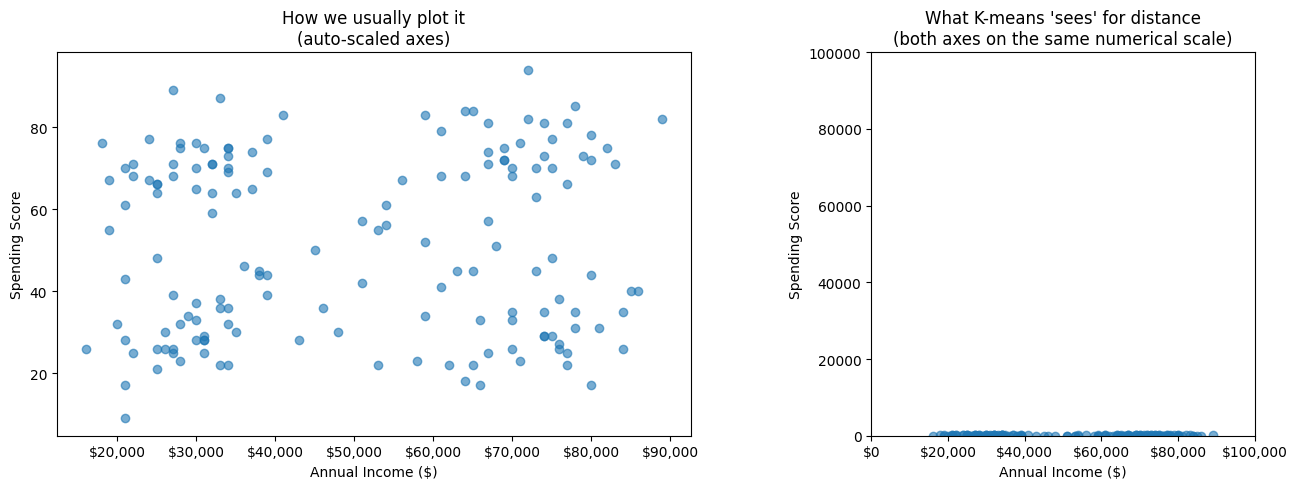

In [4]:
# Side-by-side: how we usually plot vs. what K-means actually "sees"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how we usually plot it (auto-scaled axes — both ranges fill the figure)
axes[0].scatter(customer_df["AnnualIncome"], customer_df["SpendingScore"], alpha=0.6)
axes[0].set_xlabel("Annual Income ($)")
axes[0].set_ylabel("Spending Score")
axes[0].set_title("How we usually plot it\n(auto-scaled axes)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))

# Right: both axes on the SAME numerical scale — this is what K-means "sees"
axes[1].scatter(customer_df["AnnualIncome"], customer_df["SpendingScore"], alpha=0.6)
axes[1].set_xlabel("Annual Income ($)")
axes[1].set_ylabel("Spending Score")
axes[1].set_title("What K-means 'sees' for distance\n(both axes on the same numerical scale)")
axes[1].set_xlim(0, 100000)
axes[1].set_ylim(0, 100000)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

**Left panel:** matplotlib **auto-scaled** each axis so the data fills the figure. Looking at this, ask yourself:

> How many groups do you think might exist in this data?

**Right panel:** the same data, but with both axes forced onto the **same numerical scale** — which is what K-means is really doing when it computes distance. The spending score collapses into an almost-invisible strip at the bottom.

Why? K-means measures how "close" two customers are using **distance** in the feature space. The two features are on very different numerical scales:

- Annual income ranges from about \$16,000 to about \$89,000
- Spending score ranges from about 9 to about 94

If we feed these raw numbers to K-means, a difference of \$1,000 in income counts **the same** as a difference of 1,000 spending-score points — but the spending score only goes up to 100. In effect, income would dominate the distance entirely and the spending score would be ignored.

On the right, the spending score collapses into an almost-invisible thin strip at the bottom. From the perspective of distance, the spending information has been **wiped out** by the income scale.

The fix is **standardization**: rescale each feature so that it has mean 0 and standard deviation 1. After standardization, both features have a similar spread, and neither can dominate the distance.

In [5]:
# Select only the feature columns for clustering
X = customer_df[["AnnualIncome", "SpendingScore"]]

# Standardize the features so each one has mean 0 and standard deviation 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier viewing
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=["AnnualIncome_scaled", "SpendingScore_scaled"]
)
X_scaled_df.head()

,AnnualIncome_scaled,SpendingScore_scaled
0,0.739399,-0.841446
1,1.247941,-1.348037
2,-0.832458,0.355951
3,-0.832458,0.908595
4,-1.156075,0.678327


Now let us draw the same equal-axis plot on the standardized data — this is what K-means will actually see.

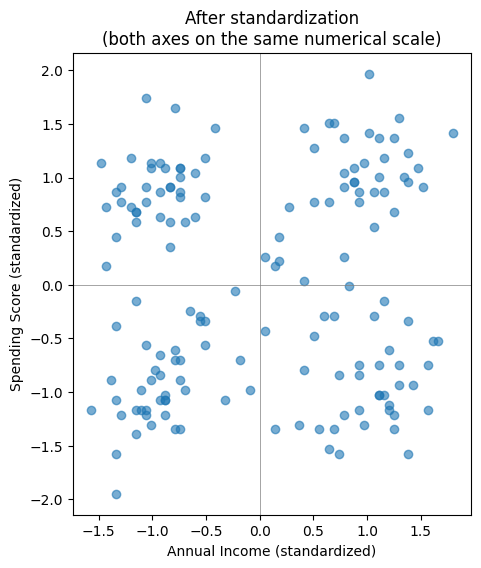

In [6]:
# Plot the standardized data on equal axes
plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.6)
plt.xlabel("Annual Income (standardized)")
plt.ylabel("Spending Score (standardized)")
plt.title("After standardization\n(both axes on the same numerical scale)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.gca().set_aspect("equal")
plt.show()

Now both features contribute on equal footing, the four blob-like groups are clearly visible, and K-means will use distance fairly. **This is why we always standardize before running K-means on features with different scales.**

## 8. Run K-means clustering

Suppose we decide to use **k = 4**, meaning we want the algorithm to divide the customers into 4 groups.

For teaching purposes, we will do this in **two separate steps**:

- `fit()` — the model learns the cluster centers
- `predict()` — the model assigns each point to a cluster

This is slightly longer than `fit_predict()`, but it makes the two stages easier to see.

**About the parameters:**

- `n_clusters=4` — we are asking for 4 clusters
- `n_init=10` — run K-means 10 times with different random initial centroids and keep the best result (this protects against poor random starts)
- `random_state=42` — fixes the random seed so we all get the same result

In [9]:
# Create the KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model to the scaled data (the model learns the centroids)
kmeans.fit(X_scaled)

# Predict the cluster label for each observation
clusters = kmeans.predict(X_scaled)

print(clusters) # show a list of cluster #

# Store the cluster labels in the original DataFrame
customer_df["Cluster"] = clusters

# Display the first 10 rows of the updated DataFrame
customer_df.head(10)

[2 2 3 3 3 2 2 3 1 2 3 2 0 0 2 1 2 0 2 0 3 1 3 1 2 0 1 3 1 1 0 3 0 0 1 0 3
 1 0 1 3 0 1 2 2 3 0 0 2 3 1 3 0 3 1 3 2 1 0 1 2 0 1 3 1 2 1 0 0 0 0 1 2 2
 1 1 2 3 3 3 0 0 0 2 2 0 0 2 0 0 2 1 0 2 0 3 0 2 1 1 3 1 2 1 0 2 2 1 3 3 3
 1 0 2 1 2 1 1 3 0 0 2 2 2 3 2 1 0 3 2 3 3 3 2 3 1 3 3 1 3 0 1 0 0 3 3 1 2
 0 0 1 1 1 0 0]


,AnnualIncome,SpendingScore,Cluster
0,66000,33,2
1,77000,22,2
2,32000,59,3
3,32000,71,3
4,25000,66,3
5,78000,31,2
6,59000,34,2
7,24000,77,3
8,75000,70,1
9,78000,35,2


## 9. Inspect the clustering result

The new column `Cluster` contains the cluster label for each customer.

> **Important:** the labels 0, 1, 2, and 3 are just **names**. They do not mean better or worse, and the numbering may change if you re-run K-means with a different random seed.

Three things are useful to look at:

1. how many customers are in each cluster
2. the **average customer** in each cluster (this is the business interpretation)
3. the **centroids** that K-means found (the geometric centers in feature space)

In [10]:
# 1. How many customers are in each cluster?
customer_df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,42
1,39
2,37
3,37


In [11]:
# 2. The "average customer" in each cluster
#    This is the most useful summary for the business question.
customer_df.groupby("Cluster")[["AnnualIncome", "SpendingScore"]].mean().round(0)

,AnnualIncome,SpendingScore
Cluster,,
0,31143.0,32.0
1,69231.0,72.0
2,71919.0,32.0
3,29243.0,71.0


### What is `kmeans.cluster_centers_` and why `inverse_transform`?

After we call `fit()`, the trained `KMeans` object remembers the centroids it learned. They are stored in an attribute called **`cluster_centers_`**: a small array with one row per cluster (4 rows here, since $k = 4$) and one column per feature (annual income, spending score).

But there is a catch. We trained K-means on the **standardized** data `X_scaled`, so `cluster_centers_` is also in **standardized units**. A coordinate like `-1.2` means "1.2 standard deviations below the mean," not "minus \$1.20." That is not readable for a marketing audience.

To convert the centroids back to dollars and spending-score points, we apply the **inverse** of the standardization: `scaler.inverse_transform(...)`. This is the same `scaler` we fit earlier, but now we run it backwards — undoing the rescaling so we can read the centroids in the original units.

In [12]:
# 3. The centroids found by K-means, in standardized units
centers_scaled = kmeans.cluster_centers_
print("Centroids in standardized units:")
print(centers_scaled.round(2))

# Convert them back to the original (dollars and spending score) units
centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers, columns=["AnnualIncome", "SpendingScore"]).round(0)
print("\nCentroids in original units:")
centers_df

Centroids in standardized units:
[[-0.87 -0.89]
 [ 0.89  0.97]
 [ 1.01 -0.91]
 [-0.96  0.9 ]]

Centroids in original units:


,AnnualIncome,SpendingScore
0,31143.0,32.0
1,69231.0,72.0
2,71919.0,32.0
3,29243.0,71.0


> **Centroid intuition:** the centroid of a cluster is essentially the **profile of an average customer** in that group. If a centroid is at (income = \$29,000, spending = 71), then the typical customer in that cluster earns about \$29,000 a year and has a spending score of about 71. This is exactly the kind of summary a marketing team would use.

## 10. Visualize the clustering result

Now let us color the points by cluster and plot the centroids on top.

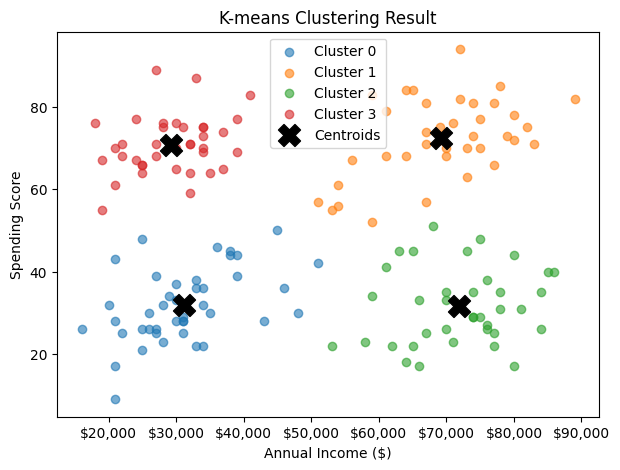

In [13]:
# Create a new figure
plt.figure(figsize=(7, 5))

# Loop through each cluster label and plot its points
for cluster_id in sorted(customer_df["Cluster"].unique()):
    cluster_data = customer_df[customer_df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["AnnualIncome"],
        cluster_data["SpendingScore"],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )

# Plot the centroids as large black X marks
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

# Labels and title
plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score")
plt.title("K-means Clustering Result")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x):,}")
)
plt.legend()
plt.show()

## 11. Interpreting the clusters

Look at the centroid table together with the scatter plot. Each cluster tells a small story about the customers in it. With four groups, a typical pattern in this kind of customer data is:

- **low income, high spending** — younger customers who spend a large share of their income
- **high income, high spending** — luxury shoppers
- **low income, low spending** — frugal customers, perhaps students
- **high income, low spending** — wealthy savers

You will also notice that some customers near the middle of the plot are not obviously in any of the four corners. K-means still has to assign them to one of the four clusters — it picks whichever centroid is closest. This is a normal feature of clustering real data: not every observation is a textbook member of its group.

This is why clustering is useful in business: it helps us **discover groups** that may support different marketing strategies, even when no one has labeled the data in advance.

## 12. Predicting the cluster for a new customer

Once K-means has been trained, we can use it to predict the cluster for a **new** customer who was not in the training data. This is what `kmeans.predict()` does.

Suppose three new customers walk into our store, and we want to know which segment each one belongs to:

| Customer | Annual Income | Spending Score |
|---|---|---|
| A | \$35,000 | 70 |
| B | \$80,000 | 25 |
| C | \$55,000 | 50 |

Two important reminders before we run the code:

1. K-means was trained on **standardized** data, so we have to apply the **same scaler** to the new customers before predicting.
2. We use `scaler.transform(...)` (not `fit_transform`). The scaler must reuse the mean and standard deviation it learned from the **training** data — we are not refitting it.

In [14]:
# Three new customers
new_customers = pd.DataFrame({
    "AnnualIncome":  [35000, 80000, 55000],
    "SpendingScore": [70,    25,    50]
})

# Apply the SAME scaler used during training (transform, not fit_transform)
new_customers_scaled = scaler.transform(new_customers)

# Predict the cluster for each new customer
predicted_clusters = kmeans.predict(new_customers_scaled)

print(predicted_clusters)

# Show the result
new_customers["PredictedCluster"] = predicted_clusters
new_customers

[3 2 2]


,AnnualIncome,SpendingScore,PredictedCluster
0,35000,70,3
1,80000,25,2
2,55000,50,2


Let us also visualize the new customers on top of the existing clusters.

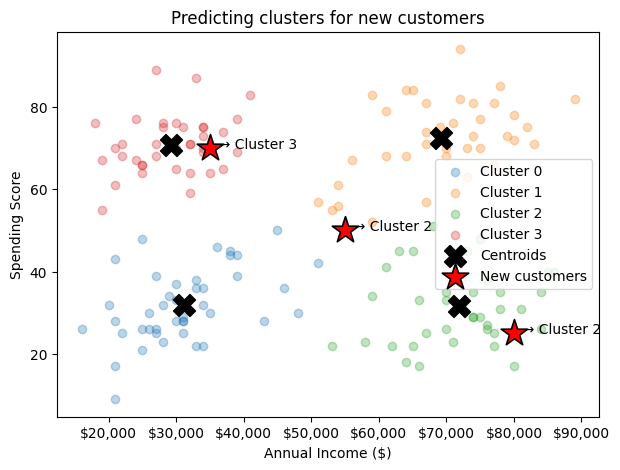

In [15]:
# Plot the existing clusters in the background, with the centroids
plt.figure(figsize=(7, 5))

for cluster_id in sorted(customer_df["Cluster"].unique()):
    cd = customer_df[customer_df["Cluster"] == cluster_id]
    plt.scatter(
        cd["AnnualIncome"], cd["SpendingScore"],
        label=f"Cluster {cluster_id}", alpha=0.3
    )

plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=250, color="black", label="Centroids")

# Plot the new customers as bright red stars
plt.scatter(
    new_customers["AnnualIncome"], new_customers["SpendingScore"],
    marker="*", s=400, color="red", edgecolors="black", linewidths=1.2,
    label="New customers", zorder=5
)

# Annotate each new customer with its predicted cluster
for _, row in new_customers.iterrows():
    plt.annotate(
        f"  → Cluster {row['PredictedCluster']}",
        (row["AnnualIncome"], row["SpendingScore"]),
        fontsize=10
    )

plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score")
plt.title("Predicting clusters for new customers")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.legend()
plt.show()

How does K-means decide? For each new customer, it computes the distance to each centroid (in standardized space) and assigns the customer to the **closest** centroid's cluster.

- Customer A and Customer B fall clearly inside one of the corner groups, and the prediction is unambiguous.
- Customer C sits near the middle of the plot. K-means **must** assign it to one of the four clusters anyway — it picks whichever centroid is nearest. This is exactly the limitation we mentioned earlier: K-means assigns every point to a cluster, even when the point is not a textbook member of any group.

## 13. How do we choose $k$? (preview)

In this lecture (and in your assignment) we are simply **told** to use $k = 4$. In practice, you would have to choose $k$ yourself, and there are several methods for doing so.

### What is "inertia"?

Before we look at the method, let us understand the number it depends on. **Inertia** is a measure of how **tight** the clusters are.

For each customer, K-means measures the distance from that customer to the centroid of the cluster the customer belongs to. Inertia is the total of all those squared distances added up across every customer.

In plain English:

- **Small inertia** → customers sit close to their cluster's center → tight, well-separated groups
- **Large inertia** → customers sit far from their cluster's center → loose, spread-out groups

There is one catch, though. Inertia will **always go down** as you add more clusters — if every customer were their own cluster, inertia would be 0! So we cannot just minimize inertia. Instead, we look for the point where adding one more cluster stops giving us much improvement.

### The elbow method

The most common quick-and-dirty method for choosing $k$ is the **elbow method**:

1. Run K-means at several values of $k$ (say $k = 1, 2, 3, \dots, 7$).
2. For each $k$, record the inertia.
3. Plot inertia vs $k$. The curve will always go down as $k$ increases, but you look for the point where it **bends sharply** and then flattens — the "elbow."
4. The $k$ at the elbow is a reasonable choice.

Below is one quick run of the elbow method on our data, just so you can see what the plot looks like. We will not go into more detail today.

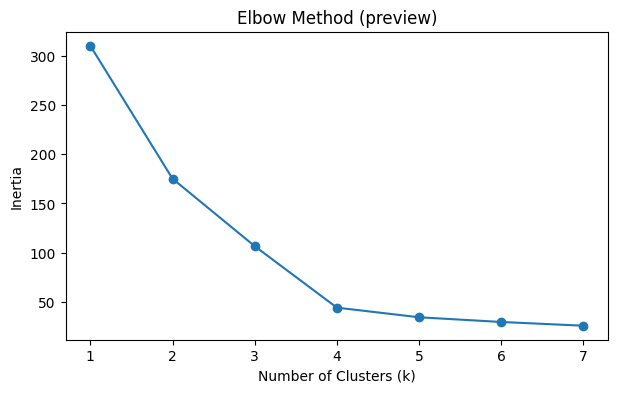

In [16]:
# Quick preview of the elbow method (no need to memorize this code)
inertias = []
k_values = range(1, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (preview)")
plt.xticks(k_values)
plt.show()

Look for the **bend** in the curve — that is the elbow, and it suggests a reasonable choice of $k$. In real data the elbow is often less sharp than in textbook examples, so it is best treated as a guideline rather than a strict rule.

The elbow method is not the only option. Another common choice is the **silhouette score**, which we may revisit in a later lecture. For today, just remember that the elbow plot exists and is a quick first thing to try.

## 14. Important limitations of K-means

K-means is useful, but it has limitations worth keeping in mind:

1. We must **choose $k$ in advance**.
2. Results depend on **scaling** of the features.
3. Cluster labels (0, 1, 2, 3, …) are **arbitrary** names.
4. K-means assumes clusters are roughly **spherical and similar in size** — it struggles with elongated, nested, or very uneven groups.
5. It is **sensitive to initialization** (the random starting centroids), which is why we use `n_init=10`.
6. **Outliers** can pull centroids and distort the result.

## 15. Key takeaways

Today we learned:

- Clustering is an **unsupervised learning** method — there is no target variable $y$.
- This is the key contrast with **KNN** (supervised) from last week. The "K" in each method means a different thing.
- **K-means** groups observations by repeatedly assigning them to the nearest centroid and updating the centroids.
- The centroid is essentially the **profile of an average member** of its cluster, which makes it directly interpretable for business questions.
- We **scale** features before running K-means because the algorithm depends on distance, and unscaled features with very different ranges (like dollars vs. a 1–100 score) cause the larger one to dominate.
- **Choosing $k$** is its own problem — the elbow method is one quick way to think about it.

## 16. Quick check

1. Why is clustering called **unsupervised learning**?
2. In clustering, do we have a target variable $y$?
3. In K-means, what does the number $k$ mean? How is this different from the $k$ in KNN?
4. Why do we often scale variables before running K-means? Use the income vs. spending score example to explain.
5. What does a centroid represent in business terms?

## 17. Quick check — answers

*Try answering the questions yourself before looking at these.*

**1. Why is clustering called unsupervised learning?**

Because the algorithm trains using only the feature matrix $X$. There are no known target labels $y$ to learn from. The algorithm has to discover structure in the data on its own.

**2. In clustering, do we have a target variable $y$?**

No. We only have feature columns. Discovering groups, rather than predicting a known label, is the whole point of clustering.

**3. In K-means, what does $k$ mean? How is this different from the $k$ in KNN?**

In K-means, $k$ is the **number of clusters** we want the algorithm to form. In KNN, $k$ is the **number of nearest neighbors** used to predict the label of a new point. They are completely different concepts that just share a letter.

**4. Why do we often scale variables before running K-means?**

K-means measures **distance** between points. In our example, AnnualIncome ranged from about \$16,000 to \$89,000 (a span of \$73,000), while SpendingScore ranged from about 9 to 94 (a span of 85). Without scaling, a \$1,000 difference in income would weigh as much as a 1,000-point difference in spending score — but the spending score only goes up to 100. The income feature would dominate the distance calculation and the spending score would effectively be ignored. Standardization puts both features on a comparable scale so they contribute equally to the distance.

**5. What does a centroid represent in business terms?**

A centroid is the **profile of an average customer** in its cluster — the typical income, spending behavior, and so on of the members of that group. A marketing team can use the centroid to describe each segment in a single sentence, e.g., *"our luxury shoppers earn about \$69,000 a year and have an average spending score of 72."*